# Predicción del flujo turístico en Barcelona

## Resumen del proyecto

Este cuaderno documenta un análisis de las pernoctaciones turísticas mensuales en Barcelona. La variable objetivo se predice mediante una progresión de modelos: SARIMA, Regresión Lineal, Random Forest, XGBoost y LSTM.

La pregunta analítica es: **¿pueden la demanda histórica y las señales externas relacionadas con el turismo ayudar a anticipar el nivel de actividad turística de la ciudad?**

El flujo de trabajo incluye la preparación de la variable objetivo, la exploración histórica, la integración de datos externos, la ingeniería de características, la evaluación cronológica, la comparación de modelos y la interpretación operativa.


## 1. Variable objetivo: pernoctaciones

La variable objetivo procede de la Encuesta de Ocupación Hotelera del INE (https://www.ine.es). El extracto contiene registros históricos de viajeros y pernoctaciones por ciudad; en este proyecto se filtran las observaciones correspondientes a Barcelona.

Las pernoctaciones se utilizan porque reflejan una demanda sostenida de alojamiento y ofrecen una aproximación más directa a la presión sobre los servicios urbanos que el número de llegadas por sí solo. El archivo de entrada no se incluye intencionadamente; consulta `data/README.md`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Formateo datos numéricos de la columna **Total** - vienen con formato de texto usando puntos para los miles (ej. "3.401.053").

In [ ]:
import pandas as pd

# 1. Cargar el archvio
ruta_archivo = '/content/drive/MyDrive/VIU/TFM/Data/2074.csv'
df_pernoctaciones = pd.read_csv(ruta_archivo, sep=';', encoding='latin1')

print(df_pernoctaciones.head())

  Totales Territoriales Comunidades y Ciudades Autónomas    Provincias  \
0        Total Nacional                      09 Cataluña  08 Barcelona   
1        Total Nacional                      09 Cataluña  08 Barcelona   
2        Total Nacional                      09 Cataluña  08 Barcelona   
3        Total Nacional                      09 Cataluña  08 Barcelona   
4        Total Nacional                      09 Cataluña  08 Barcelona   

  Viajeros y pernoctaciones Residencia: Nivel 1  Residencia: Nivel 2  Periodo  \
0                   Viajero               Total                  NaN  2026M05   
1                   Viajero               Total                  NaN  2026M04   
2                   Viajero               Total                  NaN  2026M03   
3                   Viajero               Total                  NaN  2026M02   
4                   Viajero               Total                  NaN  2026M01   

       Total  
0  1.381.118  
1  1.184.448  
2  1.080.012  
3    943

In [ ]:
# 2. Filtrar solo por 'Pernoctaciones' (variable objetivo)
df_pernoctaciones = df_pernoctaciones[df_pernoctaciones['Viajeros y pernoctaciones'] == 'Pernoctaciones'].copy()

# 3. Limpiar la columna 'Total' (quitar puntos de miles y convertir a número entero)
df_pernoctaciones['Total'] = df_pernoctaciones['Total'].astype(str).str.replace('.', '', regex=False)
df_pernoctaciones['Total'] = pd.to_numeric(df_pernoctaciones['Total'], errors='coerce')

# 4. Formatear la columna de la Fecha (Periodo)
# Convertimos '2026M05' a un formato de fecha datetime (YYYY-MM-01)
df_pernoctaciones['Fecha'] = pd.to_datetime(df_pernoctaciones['Periodo'].str.replace('M', '-'), format='%Y-%m')

# 5. Ordenar cronológicamente
df_pernoctaciones = df_pernoctaciones.sort_values(by='Fecha', ascending=True)

# 6. Crear el DataFrame Final de la variable objetivo
y = df_pernoctaciones[['Fecha', 'Total']].rename(columns={'Total': 'Pernoctaciones'})
y.set_index('Fecha', inplace=True)

# 7. Recortar a partir de 2015
y = y[y.index >= '2015-01-01']

print("Tamaño de la serie temporal:", y.shape)
print(y.head())

Tamaño de la serie temporal: (137, 1)
            Pernoctaciones
Fecha                     
2015-01-01         1289665
2015-02-01         1414753
2015-03-01         1949998
2015-04-01         2406658
2015-05-01         2879253


In [ ]:
ruta_guardado_y = '/content/drive/MyDrive/VIU/TFM/Data/pernoctaciones_limpio.csv'
y.to_csv(ruta_guardado_y)
print(f"¡Archivo guardado con éxito en: {ruta_guardado_y}!")

¡Archivo guardado con éxito en: /content/drive/MyDrive/VIU/TFM/Data/pernoctaciones_limpio.csv!


## 2. Exploración de la serie histórica

Este gráfico es un diagnóstico previo al modelado. Conviene observar la estacionalidad anual, los cambios en el nivel de largo plazo, el shock excepcional de la COVID-19 y la recuperación posterior. La repetición estacional visible motiva el uso de un modelo estacional como SARIMA.


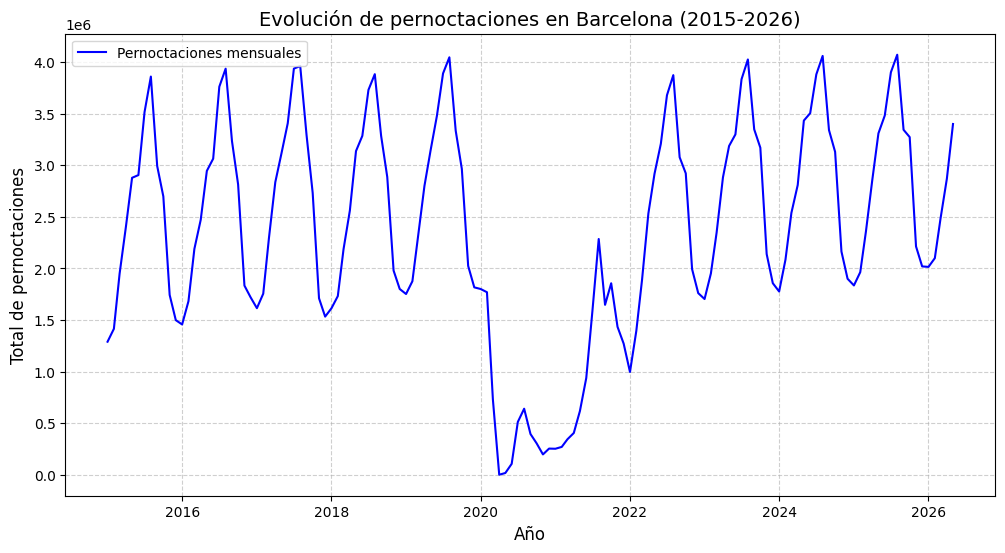

In [ ]:
import matplotlib.pyplot as plt

# Graficar la serie temporal completa
plt.figure(figsize=(12, 6))
plt.plot(y.index, y['Pernoctaciones'], color='blue', linewidth=1.5, label='Pernoctaciones mensuales')
plt.title('Evolución de pernoctaciones en Barcelona (2015-2026)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total de pernoctaciones', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 3. Variables externas

El proyecto añade señales contextuales porque la demanda turística depende de más factores que su propia historia. Todas las fuentes externas deben alinearse finalmente mediante el mismo índice mensual de fechas.


## Clima: AEMET

AEMET OpenData proporciona observaciones meteorológicas históricas. El proyecto utiliza información climática mensual, especialmente la temperatura media y la precipitación acumulada, porque el clima puede influir en la demanda de viajes y en el comportamiento estacional. La disponibilidad de la API y el formato de sus respuestas pueden cambiar con el tiempo.


In [ ]:
import pandas as pd
import requests

#2015

url_final_aemet = "https://opendata.aemet.es/opendata/sh/cd7b5b0c"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2015 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2015.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,glo,hr,n_gra,n_fog,inso,q_max,nw_55,...,w_med,nt_00,ti_max,n_nie,tm_mes,tm_max,nv_0100,q_min,np_010,fecha
0,0076,48.1(02),5,34470,72,0,0,3.9,1024.8(31),0,...,14,0,18.6,0,18.1,21.8,0,1005.9(11),7,2015-10
1,0076,15.9(02),1,28044,70,0,1,3.6,1035.4(30),3,...,15,0,14.1,0,14.6,19.0,0,1000.9(21),2,2015-11
2,0076,0.3(06),2,19021,78,0,0,2.2,1037.1(09),0,...,13,0,14.1,0,12.6,16.8,0,1019.8(13),0,2015-12
3,0076,48.1(02/oct),40,598540,68,0,6,NaN,1040.9(09/ene),21,...,16,0,8.0,0,17.5,21.4,0,984.8(31/ene),43,2015-13
4,0076,7.5(19),3,23193,66,0,0,2.9,1040.9(09),3,...,16,0,8.2,0,10.0,14.7,0,984.8(31),2,2015-1


In [ ]:
#2016

url_final_aemet = "https://opendata.aemet.es/opendata/sh/1450080e"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2016 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2016.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,glo,hr,n_gra,n_fog,inso,q_max,nw_55,...,w_med,nt_00,ti_max,n_nie,tm_mes,tm_max,nv_0100,q_min,np_010,fecha
0,0076,47.7(12),10,27040,78,0,0,3.2,1031.5(28),1,...,14,0,16.6,0,18.9,22.1,0,998.9(14),10,2016-10
1,0076,40.4(27),3,23844,72,0,0,4.4,1033.3(30),4,...,16,0,14.9,0,14.3,18.4,0,999.9(23),7,2016-11
2,0076,13.9(19),3,20518,74,0,0,4.2,1037.0(28),3,...,17,0,11.2,0,11.6,16.0,0,1010.8(19),3,2016-12
3,0076,47.7(12/oct),39,NaN,68,NaN,NaN,NaN,1037.0(28/dic),27,...,16,0,11.2,NaN,17.5,21.3,0,987.2(27/feb),54,2016-13
4,0076,1.2(04),4,21272,65,0,0,2.0,1036.1(24),5,...,15,0,11.9,0,12.2,16.1,0,999.7(04),1,2016-1


In [ ]:
#2017

url_final_aemet = "https://opendata.aemet.es/opendata/sh/ca599e75"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2017 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2017.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,glo,hr,n_gra,n_fog,inso,q_max,nw_55,...,w_med,nt_00,ti_max,n_nie,tm_mes,tm_max,nv_0100,q_min,np_010,fecha
0,0076,37.5(18),2,38791,72,0,1,6.5,1028.1(15),1,...,14,0,19.6,0,20.1,23.9,0,1005.1(19),2,2017-10
1,0076,4.9(04),2,27623,60,0,0,5.9,1030.2(27),0,...,14,0,14.3,0,13.3,18.4,0,1005.3(29),1,2017-11
2,0076,1.1(11),2,18319,61,0,0,3.5,1036.5(21),2,...,15,0,8.6,0,9.9,14.7,0,988.5(11),2,2017-12
3,0076,64.7(24/mar),35,595524,66,0,3,6.7,1036.5(21/dic),27,...,16,1,8.4,0,17.6,21.6,0,987.7(04/mar),42,2017-13
4,0076,18.6(27),8,20258,66,0,0,3.6,1030.8(07),8,...,18,1,8.4,0,9.0,13.2,0,1008.3(10),4,2017-1


In [ ]:
#2018

url_final_aemet = "https://opendata.aemet.es/opendata/sh/a7905890"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2018 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2018.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,glo,hr,n_gra,n_fog,inso,q_max,nw_55,...,w_med,nt_00,ti_max,n_nie,tm_mes,tm_max,nv_0100,q_min,np_010,fecha
0,0076,24.1(30),7,35293,73,0,0,5.5,1026.4(23),5,...,16,0,13.1,0,19.0,22.9,0,990.5(29),11,2018-10
1,0076,60.4(15),7,20713,78,0,0,3.1,1025.9(13),0,...,14,0,12.6,0,14.1,18.0,0,999.4(19),7,2018-11
2,0076,4.3(13),1,19837,75,0,0,3.7,1030.9(26),0,...,14,0,11.7,0,12.0,16.2,0,1002.9(13),1,2018-12
3,0076,74.0(30/ago),55,571832,68,1,2,6.6,1037.0(28/ene),NaN,...,16,0,5.1,1,17.8,21.6,0,987.4(01/mar),69,2018-13
4,0076,33.6(26),4,24959,65,0,0,5.1,1037.0(28),5,...,17,0,12.2,0,12.1,16.5,0,997.9(06),5,2018-1


In [ ]:
#2019

url_final_aemet = "https://opendata.aemet.es/opendata/sh/0d6a6504"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2019 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2019.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,glo,hr,n_gra,n_fog,inso,q_max,nw_55,...,w_med,nt_00,ti_max,n_nie,tm_mes,tm_max,nv_0100,q_min,np_010,fecha
0,0076,43.6(22),6,34664,72,0,1,5.3,1022.8(10),2,...,16,0,18.8,0,19.8,23.6,0,1001.9(23),4,2019-10
1,0076,8.3(22),2,25620,65,0,0,4.5,1020.7(29),6,...,15,0,14.1,0,13.5,18.0,0,988.6(23),4,2019-11
2,0076,68.9(04),3,18406,73,0,0,2.7,1033.9(30),8,...,17,0,14.5,0,12.8,16.6,0,993.8(21),4,2019-12
3,0076,72.9(02/sep),45,599972,68,2,5,7.1,1035.8(14/feb),NaN,...,17,0,10.3,0,17.5,21.5,0,988.6(23/nov),45,2019-13
4,0076,13.2(20),4,24650,64,0,0,4.3,1032.8(04),3,...,15,0,10.3,0,9.4,14.1,0,994.4(23),3,2019-1


In [ ]:
#2020

url_final_aemet = "https://opendata.aemet.es/opendata/sh/c1543912"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2020 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2020.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,hr,n_gra,n_fog,inso,q_max,q_mar,q_med,...,tm_max,nv_0100,q_min,np_010,fecha,nw_55,w_racha,nw_91,w_rec,glo
0,0076,74.5(10),5,67,0,0,6.4,1026.7(29),1015.9,1015.3,...,22.0,0,988.7(02),4,2020-10,NaN,NaN,NaN,NaN,NaN
1,0076,32.5(27),7,79,0,1,3.8,1030.2(21),1022.4,1021.8,...,19.0,0,1003.8(28),6,2020-11,3,99/18.1(27),0,385,NaN
2,0076,21.0(17),4,68,0,3,3.2,1028.0(21),1012.0,1011.4,...,14.7,0,989.7(28),3,2020-12,4,31/18.6(28),0,352,NaN
3,0076,87.9(21/ene),58,71,0,9,6.7,1034.0(22/feb),1017.5,1016.9,...,21.5,0,988.7(02/oct),60,2020-13,NaN,NaN,NaN,NaN,NaN
4,0076,87.9(21),5,73,0,0,3.8,1033.0(01),1025.0,1024.4,...,14.9,0,1015.8(28),5,2020-1,5,18/29.2(21),1,458,NaN


In [ ]:
#2021

url_final_aemet = "https://opendata.aemet.es/opendata/sh/3ac85787"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2021 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2021.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,hr,n_gra,n_fog,inso,q_max,q_mar,q_med,...,tm_mes,tm_max,nv_0100,q_min,np_010,fecha,nw_55,w_racha,nw_91,w_rec
0,0076,20.7(03),4,71,0,0,6.0,1026.8(19),1019.1,1018.5,...,18.7,22.8,0,1005.7(31),5,2021-10,NaN,NaN,NaN,NaN
1,0076,50.6(24),5,68,1,0,3.4,1029.7(19),1014.2,1013.6,...,13.1,17.1,0,996.5(27),8,2021-11,NaN,NaN,NaN,NaN
2,0076,0.5(01),2,68,0,0,3.7,1031.2(17),1017.9,1017.3,...,12.0,16.4,0,1003.9(08),0,2021-12,NaN,NaN,NaN,NaN
3,0076,50.6(24/nov),53,69,1,1,6.1,1036.6(14/feb),1016.9,1016.2,...,17.3,21.0,0,996.5(08/feb),44,2021-13,NaN,NaN,NaN,NaN
4,0076,14.4(09),5,70,0,0,3.5,1027.9(18),1014.3,1013.7,...,9.0,13.0,0,997.7(22),5,2021-1,5,29/24.2(22),0,397


In [ ]:
#2022

url_final_aemet = "https://opendata.aemet.es/opendata/sh/b9fd6cac"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2022 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2022.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,hr,n_gra,n_fog,inso,q_max,q_mar,q_med,...,tm_mes,tm_max,nv_0100,q_min,np_010,fecha,nw_55,w_racha,nw_91,w_rec
0,0076,35.2(07),3,76,0,0,6.0,1027.4(06),1020.4,1019.8,...,21.2,24.8,0,1012.8(21),1,2022-10,NaN,NaN,NaN,NaN
1,0076,23.0(09),2,68,0,0,3.8,1028.8(11),1016.6,1016.0,...,16.2,20.2,0,1001.2(21),3,2022-11,NaN,NaN,NaN,NaN
2,0076,13.8(08),4,76,0,1,3.1,1030.8(27),1015.3,1014.7,...,12.6,16.6,0,995.1(15),4,2022-12,NaN,NaN,NaN,NaN
3,0076,45.9(17/ago),51,NaN,1,4,6.6,1034.9(13/ene),1017.6,1017.0,...,NaN,NaN,0,995.1(15/dic),34,2022-13,NaN,NaN,NaN,NaN
4,0076,13.9(04),3,67,0,1,4.6,1034.9(13),1025.7,1025.1,...,9.5,14.5,0,1003.2(04),1,2022-1,NaN,NaN,NaN,NaN


In [ ]:
#2023

url_final_aemet = "https://opendata.aemet.es/opendata/sh/1b5c3000"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2023 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2023.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,hr,n_gra,n_fog,inso,q_max,nw_55,q_mar,...,w_med,nt_00,ti_max,n_nie,tm_mes,tm_max,nv_0100,q_min,np_010,fecha
0,0076,53.6(15),5,71,0,0,6.6,1026.0(03),1,1014.1,...,17,0,19.4,0,20.9,24.5,0,986.9(20),4,2023-10
1,0076,0.6(02),5,66,0,2,3.9,1026.4(18),NaN,1014.0,...,16,0,15.0,0,15.0,18.9,0,991.6(04),0,2023-11
2,0076,1.1(07),5,NaN,0,0,3.6,1038.2(17),NaN,1019.5,...,13,NaN,NaN,0,NaN,NaN,0,993.8(01),1,2023-12
3,0076,53.6(15/oct),45,NaN,0,3,7.1,1038.2(17/dic),NaN,1016.7,...,16,NaN,NaN,1,NaN,NaN,0,986.9(20/oct),25,2023-13
4,0076,0.8(17),3,59,0,0,4.2,1033.5(04),NaN,1019.9,...,16,1,6.2,0,9.5,14.0,0,989.9(17),0,2023-1


In [ ]:
#2024

url_final_aemet = "https://opendata.aemet.es/opendata/sh/506ce10b"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2024 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2024.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,hr,n_gra,n_fog,inso,q_max,q_mar,q_med,...,tm_mes,tm_max,nv_0100,q_min,np_010,fecha,nw_55,w_racha,nw_91,w_rec
0,0076,33.9(25),11,76,0,0,4.9,1028.0(23),1015.6,1015.1,...,19.5,23.1,0,998.4(09),7,2024-10,NaN,NaN,NaN,NaN
1,0076,144.2(04),6,75,0,0,3.4,1028.5(30),1020.9,1020.3,...,16.0,19.6,0,1002.1(22),5,2024-11,NaN,NaN,NaN,NaN
2,0076,30.3(12),4,70,0,0,3.6,1039.4(16),1024.1,1023.5,...,11.4,15.7,0,1009.0(09),3,2024-12,4,30/22.8(07),0,356
3,0076,144.2(04/nov),73,NaN,0,4,6.6,1039.4(16/dic),1016.5,1015.9,...,17.8,21.5,0,983.5(10/feb),57,2024-13,NaN,NaN,NaN,NaN
4,0076,11.8(05),9,70,0,0,3.6,1036.5(23),1020.9,1020.2,...,11.3,15.3,0,997.0(17),3,2024-1,NaN,NaN,NaN,NaN


In [ ]:
#2025

url_final_aemet = "https://opendata.aemet.es/opendata/sh/b7a940c2"

print("Descargando datos desde el JSON...")

respuesta = requests.get(url_final_aemet)
datos_json = respuesta.json()

df_clima_2025 = pd.DataFrame(datos_json)

print("¡Datos convertidos con éxito!")
display(df_clima_2025.head())

Descargando datos desde el JSON...
¡Datos convertidos con éxito!


,indicativo,p_max,n_cub,hr,n_gra,n_fog,inso,q_max,q_mar,q_med,...,tm_mes,tm_max,nv_0100,q_min,np_010,fecha,nw_55,w_racha,nw_91,w_rec
0,0076,14.3(09),3,72,0,0,6.0,1025.6(06),1017.1,1016.6,...,19.7,23.7,0,1003.6(23),7,2025-10,NaN,NaN,NaN,NaN
1,0076,12.4(06),3,64,0,0,4.6,1024.9(03),1015.1,1014.5,...,14.2,18.6,0,1003.3(24),3,2025-11,NaN,NaN,NaN,NaN
2,0076,30.2(27),10,80,0,0,2.1,1027.2(13),1016.2,1015.6,...,11.9,15.4,0,1001.7(23),10,2025-12,2,09/17.5(26),0,362
3,0076,48.7(28/ago),58,71,3,7,6.5,1032.5(05/feb),1016.5,1015.9,...,18.1,21.8,0,995.8(13/mar),57,2025-13,NaN,NaN,NaN,NaN
4,0076,6.5(16),7,65,0,0,4.0,1031.5(01),1018.7,1018.0,...,11.3,15.8,0,1002.6(06),1,2025-1,5,08/20.6(16),0,386


In [ ]:
# UNIFICAR TODOS LOS DF

df_clima_total = pd.concat([
    df_clima_2015,
    df_clima_2016,
    df_clima_2017,
    df_clima_2018,
    df_clima_2019,
    df_clima_2020,
    df_clima_2021,
    df_clima_2022,
    df_clima_2023,
    df_clima_2024,
    df_clima_2025
], ignore_index=True)

# GUARDAR EN EXCEL Y CSV
print("Guardando archivos en local...")

nombre_excel = "clima_barcelona_historico.xlsx"
df_clima_total.to_excel(nombre_excel, index=False)

nombre_csv = "clima_barcelona_historico.csv"
df_clima_total.to_csv(nombre_csv, index=False)

print(f"¡Listo! Archivos guardados como '{nombre_excel}' y '{nombre_csv}'.")

display(df_clima_total.head())

Uniendo todos los años...
¡Unión completada! Tienes un total de 143 registros diarios.
Guardando archivos en local...
¡Listo! Archivos guardados como 'clima_barcelona_historico.xlsx' y 'clima_barcelona_historico.csv'.


,indicativo,p_max,n_cub,glo,hr,n_gra,n_fog,inso,q_max,nw_55,...,w_med,nt_00,ti_max,n_nie,tm_mes,tm_max,nv_0100,q_min,np_010,fecha
0,0076,48.1(02),5,34470,72,0,0,3.9,1024.8(31),0,...,14,0,18.6,0,18.1,21.8,0,1005.9(11),7,2015-10
1,0076,15.9(02),1,28044,70,0,1,3.6,1035.4(30),3,...,15,0,14.1,0,14.6,19.0,0,1000.9(21),2,2015-11
2,0076,0.3(06),2,19021,78,0,0,2.2,1037.1(09),0,...,13,0,14.1,0,12.6,16.8,0,1019.8(13),0,2015-12
3,0076,48.1(02/oct),40,598540,68,0,6,NaN,1040.9(09/ene),21,...,16,0,8.0,0,17.5,21.4,0,984.8(31/ene),43,2015-13
4,0076,7.5(19),3,23193,66,0,0,2.9,1040.9(09),3,...,16,0,8.2,0,10.0,14.7,0,984.8(31),2,2015-1


In [ ]:
nombre_excel = "clima_barcelona_historico.xlsx"
df_clima_total.to_excel(nombre_excel, index=False)

nombre_csv = "clima_barcelona_historico.csv"
df_clima_total.to_csv(nombre_csv, index=False)

print(f"Archivos actualizados y guardados como '{nombre_excel}' y '{nombre_csv}'.")

Actualizando archivos en local con la versión limpia...
Archivos actualizados y guardados como 'clima_barcelona_historico.xlsx' y 'clima_barcelona_historico.csv'.


## Variables de calendario

Esta sección crea indicadores diarios para los festivos de Catalunya, los fines de semana y los días libres reales, y después los agrega a frecuencia mensual. La interpretación de negocio es que el número de días disponibles para el ocio puede influir en la demanda de alojamiento.


In [ ]:
import holidays

# 1. Calendario diario base
calendario_diario = pd.DataFrame({
    'fecha': pd.date_range(start='2015-01-01', end='2026-12-31', freq='D')
})

# 2. Festivos oficiales de Catalunya (Código 'CT')
# Esto incluye tanto festivos nacionales como autonómicos (Sant Joan, La Diada, Sant Esteve...)
festivos_catalunya = holidays.Spain(subdiv='CT', years=range(2015, 2026))

# 3. FEATURE ENGINEERING: Clasificación de días
# 1 = festivo, 0 = no lo es
calendario_diario['es_festivo'] = calendario_diario['fecha'].apply(lambda x: 1 if x in festivos_catalunya else 0)

# Asignar 1 si es fin de semana (sábado=5, domingo=6)
calendario_diario['es_fin_semana'] = calendario_diario['fecha'].dt.dayofweek.isin([5, 6]).astype(int)

# 4. VARIABLE: "Días Libres Reales"
# Si un festivo cae en domingo, no queremos contarlo dos veces.
# Esta columna vale 1 si el día es festivo O fin de semana.
calendario_diario['dia_libre_real'] = ((calendario_diario['es_festivo'] == 1) | (calendario_diario['es_fin_semana'] == 1)).astype(int)

# AGREGACIÓN MENSUAL (Sincronizar con el INE y AEMET)

df_calendario_mensual = calendario_diario.groupby(calendario_diario['fecha'].dt.to_period('M')).agg({
    'es_festivo': 'sum',       # Número total de festivos puros en ese mes
    'es_fin_semana': 'sum',    # Número de sábados y domingos
    'dia_libre_real': 'sum'    # Total absoluto de días de descanso (métrica predictora clave)
}).reset_index()

# 5. Formatear la fecha como índice al inicio del mes
df_calendario_mensual['fecha'] = df_calendario_mensual['fecha'].dt.to_timestamp()
df_calendario_mensual.set_index('fecha', inplace=True)

print("\n¡Matriz de calendario finalizada!")
display(df_calendario_mensual.head(12))


¡Matriz de calendario finalizada!


,es_festivo,es_fin_semana,dia_libre_real
fecha,,,
2015-01-01,2,9,11
2015-02-01,0,8,8
2015-03-01,0,9,9
2015-04-01,2,8,10
2015-05-01,1,10,11
2015-06-01,1,8,9
2015-07-01,0,8,8
2015-08-01,1,10,10
2015-09-01,1,8,9


In [ ]:
ruta_carpeta = "/content/drive/MyDrive/VIU/TFM/Data/"
df_calendario_mensual.to_csv(ruta_carpeta + 'calendario_mensual.csv')

print("¡Archivo 'calendario_mensual.csv' guardado correctamente en Drive!")

¡Archivo 'calendario_mensual.csv' guardado correctamente en Drive!


## Movilidad: AENA

Las estadísticas aeroportuarias de AENA proporcionan una señal de movilidad para Barcelona-El Prat. El cuaderno normaliza los nombres de los meses en español, limpia los valores numéricos, elimina los meses duplicados y calcula el crecimiento de las llegadas. Las llegadas aeroportuarias son una señal plausible de demanda, pero una correlación no debe interpretarse como causalidad.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import glob

ruta_carpeta = "/content/drive/MyDrive/VIU/TFM/Data/"
rutas_archivos = glob.glob(ruta_carpeta + "*Operaciones*.csv")

print(f"Archivos encontrados para fusionar: {len(rutas_archivos)}")

meses_dict = {
    'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
    'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
    'septiembre': '09', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
}

def parsear_fecha_aena(texto):
    if pd.isna(texto): return None
    partes = str(texto).lower().split('de')
    if len(partes) == 2:
        mes_str = partes[0].strip()
        anio_str = partes[1].strip()
        mes_num = meses_dict.get(mes_str, '01')
        return f"{anio_str}-{mes_num}-01"
    return None

lista_dataframes = []

# BUCLE DE LIMPIEZA
for ruta in rutas_archivos:
    # Intetar abrir el archivo con diferentes codificaciones
    try:
        df_temp = pd.read_csv(ruta, dtype=str, encoding='utf-8')
    except UnicodeDecodeError:
        try:
            df_temp = pd.read_csv(ruta, dtype=str, encoding='utf-16')
        except UnicodeDecodeError:
            df_temp = pd.read_csv(ruta, dtype=str, encoding='latin1')

    # Limpieza de operaciones
    # Se quitan espacios en blanco
    columna_operaciones = df_temp['Operaciones Totales'].str.strip()
    df_temp['llegadas'] = columna_operaciones.str.replace('.', '').astype(int)

    # Limpieza de fechas
    df_temp['fecha'] = df_temp['Mes'].apply(parsear_fecha_aena)
    df_temp['fecha'] = pd.to_datetime(df_temp['fecha'])

    lista_dataframes.append(df_temp[['fecha', 'llegadas']])

# UNIFICACIÓN
if lista_dataframes:
    df_aena_total = pd.concat(lista_dataframes, ignore_index=True)
    df_aena_total = df_aena_total.sort_values('fecha').drop_duplicates(subset=['fecha']).reset_index(drop=True)
    df_aena_total['crecimiento_llegadas'] = df_aena_total['llegadas'].pct_change().fillna(0)
    df_aena_total.set_index('fecha', inplace=True)

    ruta_guardado = ruta_carpeta + 'aena_barcelona_historico_limpio.csv'
    df_aena_total.to_csv(ruta_guardado)

    print(f"\n¡Éxito total! Se han fusionado los archivos esquivando los errores de formato.")
    print(f"El dataset final se ha guardado en tu Drive como 'aena_barcelona_historico_limpio.csv'")
    display(df_aena_total.head(10))
else:
    print("\n[!] Sigo sin encontrar los archivos. Comprueba la ruta.")

Mounted at /content/drive

Iniciando la fusión masiva de archivos de AENA desde Drive...
Archivos encontrados para fusionar: 6

¡Éxito total! Se han fusionado los archivos esquivando los errores de formato.
El dataset final se ha guardado en tu Drive como 'aena_barcelona_historico_limpio.csv'


,llegadas,crecimiento_llegadas
fecha,,
2015-01-01,9072,0.000000
2015-02-01,8671,-0.044202
2015-03-01,10656,0.228924
2015-04-01,12346,0.158596
2015-05-01,13248,0.073060
2015-06-01,13697,0.033892
2015-07-01,14563,0.063226
2015-08-01,14508,-0.003777
2015-09-01,13510,-0.068790


## Señales digitales de demanda: Google Trends

Los indicadores de Google Trends representan el interés de búsqueda de `barcelona flights`, `barcelona hotel` y `airbnb barcelona`. Son índices relativos de intención de viaje, no volúmenes absolutos de búsquedas. La exportación original no se incluye en el repositorio público.


Los datos se extraen en .csv directamente de la web de Gooogle Trends y se cargan en el INNER JOIN

## 4. Integración mensual

El dataset maestro une la variable objetivo y las fuentes externas mediante su índice mensual de fechas. Un `INNER JOIN` conserva únicamente los meses presentes en todas las fuentes, lo que garantiza la alineación temporal, aunque puede reducir el número de observaciones utilizables si alguna fuente tiene meses ausentes.


In [ ]:
import pandas as pd

ruta_carpeta = "/content/drive/MyDrive/VIU/TFM/Data/"

try:
    print("Cargando archivos...")

    # AEMET
    df_clima = pd.read_csv(ruta_carpeta + 'clima_barcelona_historico_final.csv', parse_dates=['fecha'], index_col='fecha')

    # Pernoctaciones
    df_pernoctaciones = pd.read_csv(ruta_carpeta + 'pernoctaciones_limpio.csv', parse_dates=['Fecha'], index_col='Fecha')
    df_pernoctaciones.index.name = 'fecha'

    # AENA
    df_aena = pd.read_csv(ruta_carpeta + 'aena_barcelona_historico_limpio.csv', parse_dates=['fecha'], index_col='fecha')

    # Google Trends
    df_trends = pd.read_csv(ruta_carpeta + 'google_trends_barcelona.csv', parse_dates=['fecha'], index_col='fecha')

    # Festivos
    df_calendario = pd.read_csv(ruta_carpeta + 'calendario_mensual.csv', parse_dates=['fecha'], index_col='fecha')

    # INNER JOIN

    df_master = df_pernoctaciones.join([df_clima, df_aena, df_trends, df_calendario], how='inner')

    # Limpieza de nulos
    # df_master = df_master.dropna()

    # Guardado
    ruta_guardado_final = ruta_carpeta + 'DATASET_TFM_FINAL.csv'
    df_master.to_csv(ruta_guardado_final)

    print(f"\n¡ÉXITO TOTAL! Matriz final unificada y guardada.")
    print(f"Total de meses (filas) alineados: {len(df_master)}")
    print(f"Ruta: {ruta_guardado_final}")
    display(df_master.head())

except FileNotFoundError as e:
    print(f"\n[!] Error: No se encuentra uno de los archivos. Revisa el nombre exacto:\n{e}")
except Exception as e:
    print(f"\n[!] Ha ocurrido un error inesperado durante la fusión: {e}")

Cargando archivos...

¡ÉXITO TOTAL! Matriz final unificada y guardada.
Total de meses (filas) alineados: 132
Ruta: /content/drive/MyDrive/VIU/TFM/Data/DATASET_TFM_FINAL.csv


,Pernoctaciones,temp_media,precipitacion_total,llegadas,crecimiento_llegadas,barcelona flights,barcelona hotel,airbnb barcelona,es_festivo,es_fin_semana,dia_libre_real
fecha,,,,,,,,,,,
2015-01-01,1289665,10.0,13.6,9072,0.000000,3,69,2,2,9,11
2015-02-01,1414753,9.6,10.2,8671,-0.044202,3,77,3,0,8,8
2015-03-01,1949998,12.9,59.3,10656,0.228924,4,88,4,0,9,9
2015-04-01,2406658,15.2,11.1,12346,0.158596,3,78,4,2,8,10
2015-05-01,2879253,19.4,28.7,13248,0.073060,3,89,4,1,10,11


# 5. Feature engineering

Esta etapa traduce el conocimiento del contexto en variables de entrada para los modelos. Los retardos representan efectos diferidos, las variables móviles resumen el contexto reciente, la codificación cíclica representa la continuidad del calendario y el indicador de COVID-19 aísla un shock excepcional.

In [ ]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset
ruta_carpeta = "/content/drive/MyDrive/VIU/TFM/Data/"
df = pd.read_csv(ruta_carpeta + 'DATASET_TFM_FINAL.csv', parse_dates=['fecha'], index_col='fecha')

df_optimizada = df.copy()

# A. CODIFICACIÓN CÍCLICA DEL TIEMPO
df_optimizada['mes_num'] = df_optimizada.index.month
df_optimizada['mes_sin'] = np.sin(2 * np.pi * df_optimizada['mes_num'] / 12)
df_optimizada['mes_cos'] = np.cos(2 * np.pi * df_optimizada['mes_num'] / 12)
df_optimizada.drop(columns=['mes_num'], inplace=True)

# B. GENERACIÓN DE LAGS
variables_adelantadas = ['llegadas', 'barcelona flights', 'barcelona hotel', 'airbnb barcelona']
for var in variables_adelantadas:
    df_optimizada[f'{var}_lag_1'] = df_optimizada[var].shift(1)
    df_optimizada[f'{var}_lag_2'] = df_optimizada[var].shift(2)

# C. VENTANAS MÓVILES (Rolling Features para suavizado)
df_optimizada['temp_media_roll_3'] = df_optimizada['temp_media'].rolling(window=3).mean()
df_optimizada['google_trends_roll_3'] = df_optimizada['barcelona hotel'].rolling(window=3).mean()


# D. AUTOREGRESIÓN (Lag de la Variable Objetivo para RF y XGBoost)
# Se le da a los árboles de decisión el dato de ocupación del mes pasado
df_optimizada['pernoctaciones_lag_1'] = df_optimizada['Pernoctaciones'].shift(1)

# E. VARIABLE DUMMY DE SHOCK (Efecto Pandemia COVID-19)
# Se marca con un 1 los meses de mayor impacto y restricción de movilidad
# (Marzo 2020 hasta Junio 2021 aprox). El resto de meses serán 0.
df_optimizada['es_covid'] = np.where(
    (df_optimizada.index >= '2020-03-01') & (df_optimizada.index <= '2021-06-01'),
    1,
    0
)

# Limpieza de filas con valores nulos generados por los shifts/rolling
df_optimizada = df_optimizada.dropna()

# Guardar la versión avanzada para modelado
ruta_optimizada = ruta_carpeta + 'DATASET_TFM_AVANZADO.csv'
df_optimizada.to_csv(ruta_optimizada)

print(f"¡Dataset optimizado!")
print(f"Nuevas dimensiones: {df_optimizada.shape[0]} meses x {df_optimizada.shape[1]} variables.")
display(df_optimizada.head())

¡Dataset optimizado!
Nuevas dimensiones: 130 meses x 25 variables.


,Pernoctaciones,temp_media,precipitacion_total,llegadas,crecimiento_llegadas,barcelona flights,barcelona hotel,airbnb barcelona,es_festivo,es_fin_semana,...,barcelona flights_lag_1,barcelona flights_lag_2,barcelona hotel_lag_1,barcelona hotel_lag_2,airbnb barcelona_lag_1,airbnb barcelona_lag_2,temp_media_roll_3,google_trends_roll_3,pernoctaciones_lag_1,es_covid
fecha,,,,,,,,,,,,,,,,,,,,,
2015-03-01,1949998,12.9,59.3,10656,0.228924,4,88,4,0,9,...,3.0,3.0,77.0,69.0,3.0,2.0,10.833333,78.000000,1414753.0,0
2015-04-01,2406658,15.2,11.1,12346,0.158596,3,78,4,2,8,...,4.0,3.0,88.0,77.0,4.0,3.0,12.566667,81.000000,1949998.0,0
2015-05-01,2879253,19.4,28.7,13248,0.073060,3,89,4,1,10,...,3.0,4.0,78.0,88.0,4.0,4.0,15.833333,85.000000,2406658.0,0
2015-06-01,2905615,23.5,10.9,13697,0.033892,4,94,4,1,8,...,3.0,3.0,89.0,78.0,4.0,4.0,19.366667,87.000000,2879253.0,0
2015-07-01,3516011,27.1,13.8,14563,0.063226,5,97,4,0,8,...,4.0,3.0,94.0,89.0,4.0,4.0,23.333333,93.333333,2905615.0,0


## 6. División cronológica entre Train / Test

Los últimos 18 meses se reservan para la prueba. La división es cronológica y no aleatoria porque un modelo de predicción debe evaluarse sobre un periodo futuro. Una división aleatoria podría exponer el entrenamiento a patrones futuros y provocar fuga de información (`data leakage`).


In [ ]:
import pandas as pd
import numpy as np

# 1. Cargar el Dataset Avanzado
ruta_carpeta = "/content/drive/MyDrive/VIU/TFM/Data/"
df = pd.read_csv(ruta_carpeta + 'DATASET_TFM_AVANZADO.csv', parse_dates=['fecha'], index_col='fecha')

# 2. Separar Variable Objetivo (y) de las Predictoras (X)
y = df['Pernoctaciones']
X = df.drop(columns=['Pernoctaciones'])

# 3. TRAIN-TEST SPLIT (Cronológico para evitar Data Leakage)
# Definimos el corte: últimos 18 meses
meses_test = 18

X_train = X.iloc[:-meses_test]
y_train = y.iloc[:-meses_test]

X_test = X.iloc[-meses_test:]
y_test = y.iloc[-meses_test:]

print(f"Entrenamiento (Train): {len(X_train)} meses (Desde {X_train.index[0].date()} hasta {X_train.index[-1].date()})")
print(f"Evaluación (Test): {len(X_test)} meses (Desde {X_test.index[0].date()} hasta {X_test.index[-1].date()})")

Entrenamiento (Train): 112 meses (Desde 2015-03-01 hasta 2024-06-01)
Evaluación (Test): 18 meses (Desde 2024-07-01 hasta 2025-12-01)


## 7. Análisis de correlación

La matriz de Pearson es una herramienta descriptiva: ayuda a identificar asociaciones y posibles problemas de multicolinealidad, pero no demuestra causalidad. El proyecto muestra asociaciones fuertes para las llegadas aeroportuarias y las pernoctaciones retardadas, además de señales positivas del interés por hoteles y de la temperatura.


Generando mapa de calor de la matriz de correlación para Selección de Características...
¡Éxito! Matriz de correlación guardada con calidad de impresión en: /content/drive/MyDrive/VIU/TFM/Data/matriz_correlacion_features.png


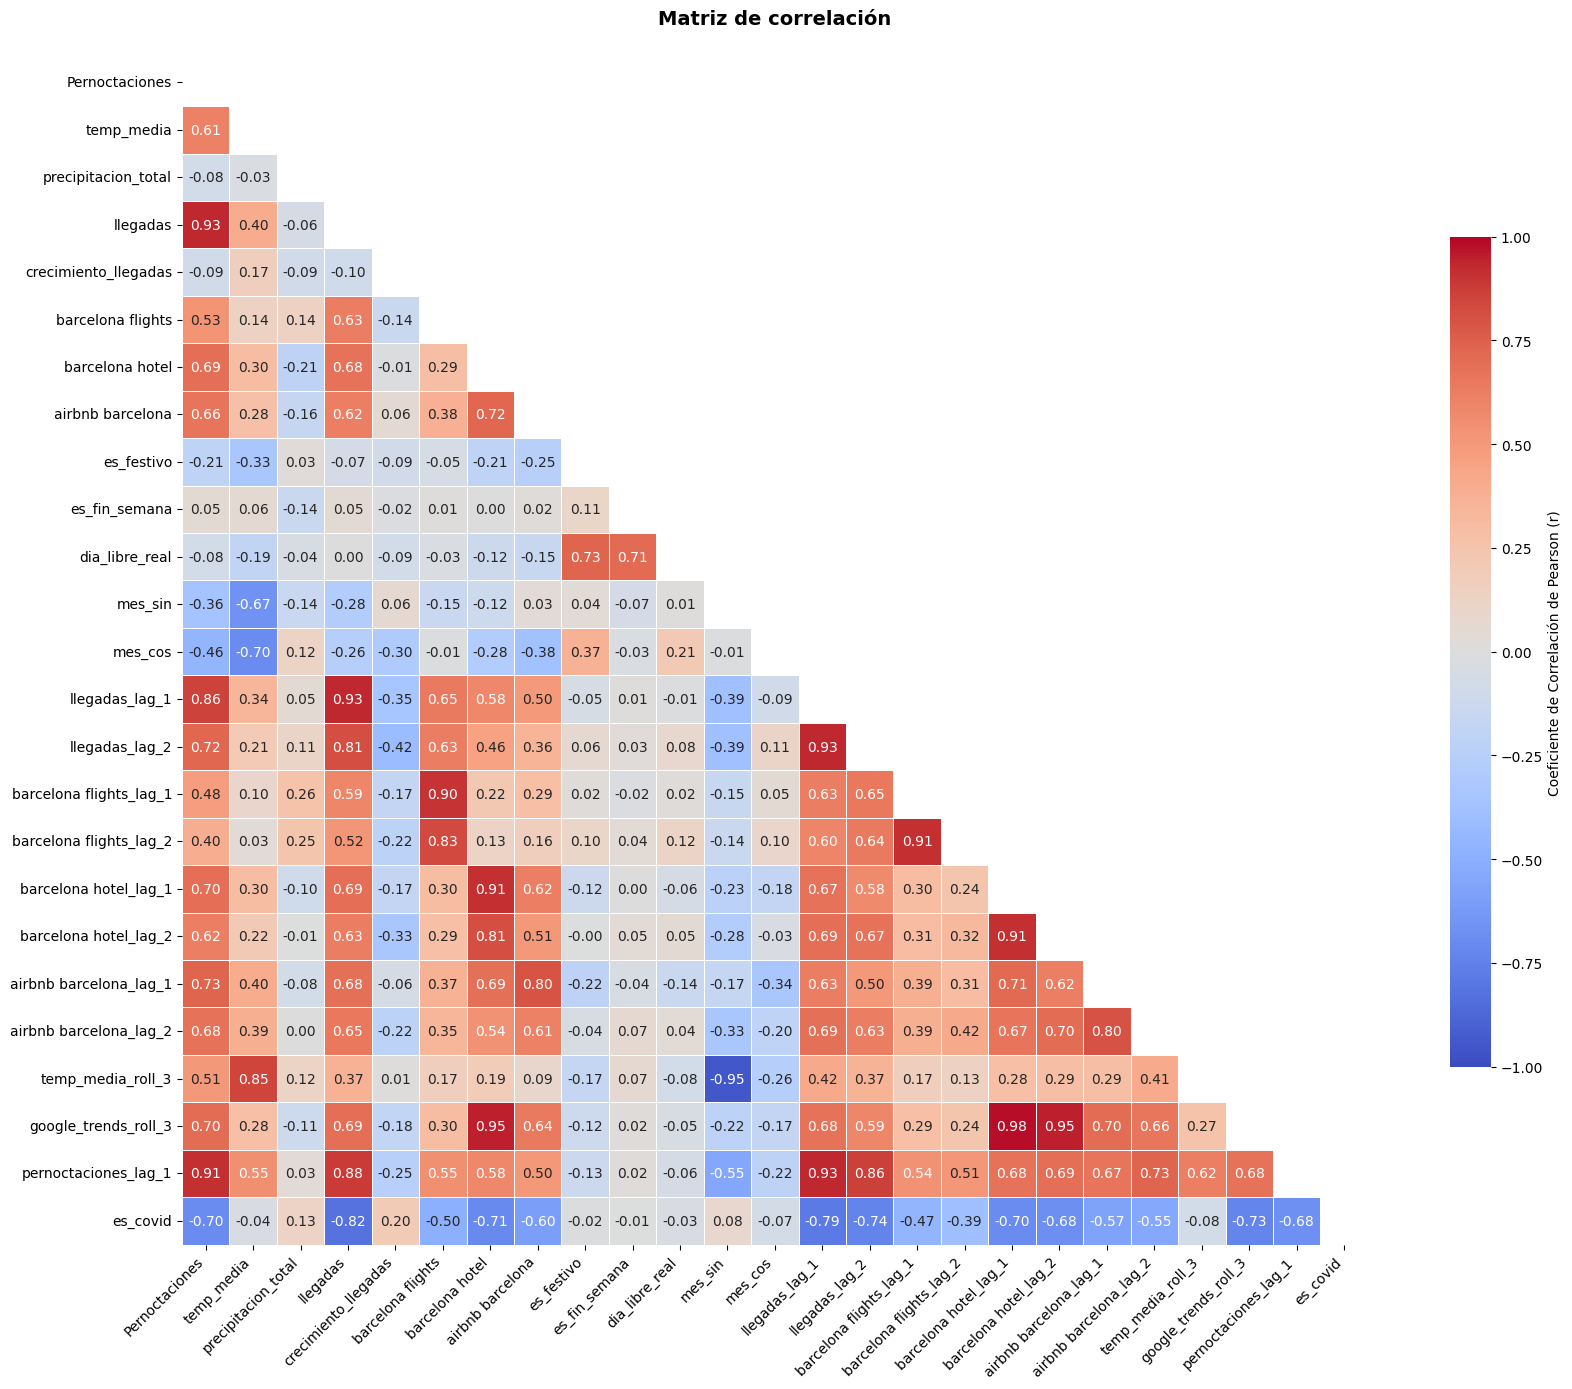

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Generando mapa de calor de la matriz de correlación para Selección de Características...")

# 1. CARGA DE DATOS
ruta_carpeta = "/content/drive/MyDrive/VIU/TFM/Data/"
df = pd.read_csv(ruta_carpeta + 'DATASET_TFM_AVANZADO.csv', parse_dates=['fecha'], index_col='fecha')

# 2. CÁLCULO DE LA MATRIZ DE CORRELACIÓN (Pearson)
matriz_corr = df.corr()


# 3. CONFIGURACIÓN DEL HEATMAP
plt.figure(figsize=(18, 14))

# Creamos una máscara booleana para la mitad superior. Al ser una matriz simétrica,
# duplicar los datos dificulta la lectura visual
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Heatmap
sns.heatmap(
    matriz_corr,
    mask=mask,
    annot=True,           # Muestra el valor numérico del coeficiente dentro de cada celda
    fmt=".2f",            # Redondeo a dos decimales
    cmap='coolwarm',      # Escala divergente idónea (Azul: Negativa, Blanco: Neutra, Rojo: Positiva)
    vmin=-1, vmax=1,      # Forzamos los límites matemáticos del coeficiente de Pearson
    square=True,          # Forzar celdas perfectamente cuadradas
    linewidths=.5,        # Línea sutil de separación entre celdas
    cbar_kws={"shrink": .7, "label": "Coeficiente de Correlación de Pearson (r)"} # Personalización de la barra lateral
)

# Ajustes de etiquetas y títulos
plt.title('Matriz de correlación',
          fontsize=14, pad=25, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()


# 4. GUARDADO
ruta_guardado = ruta_carpeta + 'matriz_correlacion_features.png'
plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')

print(f"¡Éxito! Matriz de correlación guardada con calidad de impresión en: {ruta_guardado}")
plt.show()